# Final Project Part 3
### Emeric Famechon and Karthik Gunaseelan

## BONUSES

### Section 1: Review of Part 2

Looking at Part 2, we are analyzing the dynamics of an overdamped mechanical system. The system is governed by a first-order ODE because the mass is negligible. 

$$\frac{dx}{dt} = -5000x + 0.002\sin(t)$$

In this equation, x(t) represents the displacement from equilibrium with the initial value being x(0)=1. Part 2 successfully solved this system using the Backward Euler method. We paired the Backward Euler with a standard Newton Raphson to resolve the residual equations.


The mechanical system is considered highly stiff due to the contrast between its time scales. The system feature fast transient dynamics dictated by the -5000x term. Conversely, the slow dynamics feature a sine function which operate on a slower scale. This creates a stiffness ratio of 5000 which is extremely large. Because of this stiffness, Forward Euler faces severe stability limitations requiring extremely small step sizes. This is exactly why we choose a more stable method like the Backward Euler.

### Bonus 1: PI Controller for Step Size

In [20]:
import numpy as np

# From Part 3.1
def damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func, 
                          tol=1e-8, max_iter=20, alpha_min=1e-4):
    y_guess = y_n
    total_backtracks = 0
    damping_needed = False
    alpha_history = []  
    
    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        
        if abs(g) < tol:
            return y_guess, k, True, total_backtracks, damping_needed, alpha_history
        
        g_prime = g_prime_func(y_guess, h)
        delta = -g / g_prime
        
        alpha = 1.0
        g_current = abs(g)
        backtracks_iter = 0
        
        for _ in range(10):  
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
            
            if g_new < g_current: 
                break
            
            alpha = alpha / 2.0
            backtracks_iter += 1
            total_backtracks += 1
             
            if alpha < alpha_min:
                alpha_history.append(alpha)
                return y_guess, k, False, total_backtracks, damping_needed, alpha_history
            
        if backtracks_iter > 0:
            damping_needed = True
        
        alpha_history.append(alpha) 
        y_guess = y_new
    
    return y_guess, max_iter, False, total_backtracks, damping_needed, alpha_history


# PI Controller
def adjust_step_size_pi(h_current, error, error_prev, tol, kP=0.7, kI=0.4, 
                        safety=0.9, h_min=1e-6, h_max=1.0):    
    """    
    Compute new step size using a Proportional-Integral (PI) Controller.
    """    
    if error < 1e-14:  
        h_new = h_current * 2.0    
    else:        
        if error_prev is None:
            # First step: Fall back to standard proportional control
            factor = np.sqrt(tol / error)
        else:
            # PI Control Formula
            factor = ((tol / error)**kP) * ((error_prev / tol)**kI)
            
        h_new = h_current * factor
    
    # Apply safety factor    
    h_new = safety * h_new        
    
    # Enforce bounds    
    h_new = max(h_min, min(h_max, h_new))        
    
    # Don't change h too aggressively    
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))        
    
    return h_new

# Part 3.2
def adaptive_implicit_euler(f, g_func, g_prime_func, y0, t0, t_final, h0, tol, 
                            h_min=1e-6, h_max=1.0, safety=0.9, nr_tol=1e-8, max_nr_iter=20):
    t = [t0]
    y = [y0]
    h = h0
    h_history = []
    error_history = []  
    error_prev = None  # Tracks previous error for PI controller
    
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [], 
        'damping_used': 0,
        'function_evals': 0
    }
    
    def update_evals(iters, backtracks):
        stats['function_evals'] += (iters * 2) + backtracks

    while t[-1] < t_final:
        if t[-1] + h > t_final:
            h = t_final - t[-1]
            
        current_t = t[-1]
        current_y = y[-1]
        step_nr_iters = 0
        
        # 1. Full step attempt
        y_full, iters_full, conv_full, bts_full, damped_full, _ = damped_newton_raphson(
            current_y, current_t + h, h, g_func, g_prime_func, nr_tol, max_nr_iter)
        
        step_nr_iters += iters_full
        update_evals(iters_full, bts_full)
        if damped_full: stats['damping_used'] += 1
            
        if not conv_full:
            h = max(h_min, h * 0.2)
            stats['rejected_steps'] += 1
            stats['nr_iterations'].append(step_nr_iters)
            continue
            
        # 2. Two half-steps
        h_half = h / 2.0
        y_half1, iters_h1, conv_h1, bts_h1, damped_h1, _ = damped_newton_raphson(
            current_y, current_t + h_half, h_half, g_func, g_prime_func, nr_tol, max_nr_iter)
        step_nr_iters += iters_h1
        update_evals(iters_h1, bts_h1)
        if damped_h1: stats['damping_used'] += 1
            
        if not conv_h1:
            h = max(h_min, h * 0.2)
            stats['rejected_steps'] += 1
            stats['nr_iterations'].append(step_nr_iters)
            continue
            
        y_half2, iters_h2, conv_h2, bts_h2, damped_h2, _ = damped_newton_raphson(
            y_half1, current_t + h, h_half, g_func, g_prime_func, nr_tol, max_nr_iter)
        step_nr_iters += iters_h2
        update_evals(iters_h2, bts_h2)
        if damped_h2: stats['damping_used'] += 1
            
        if not conv_h2:
            h = max(h_min, h * 0.2)
            stats['rejected_steps'] += 1
            stats['nr_iterations'].append(step_nr_iters)
            continue
            
        # 3. Error Calculation
        error = abs(y_half2 - y_full)
        stats['nr_iterations'].append(step_nr_iters) 
        
        # 4. Compute new h using the PI Controller
        h_new = adjust_step_size_pi(h, error, error_prev, tol, safety=safety, h_min=h_min, h_max=h_max)
        
        # 5. Accept/Reject based on tolerance
        if error <= tol:
            t.append(current_t + h)
            y.append(y_half2) 
            h_history.append(h)
            error_history.append(error) 
            
            stats['accepted_steps'] += 1
            error_prev = error  # Save for next iteration's PI controller
            h = h_new
        else:
            stats['rejected_steps'] += 1
            h = h_new
            
    return np.array(t), np.array(y), np.array(h_history), np.array(error_history), stats


# test Block
if __name__ == "__main__":
    def f_decay(t, x): return -15.0 * x
    def g_func_decay(y_guess, y_n, t_next, h): return y_guess - y_n - h * f_decay(t_next, y_guess)
    def g_prime_func_decay(y_guess, h): return 1.0 + 15.0 * h

    t0, t_final, y0, h0, tol = 0.0, 2.0, 1.0, 0.1, 1e-4

    t_res, y_res, h_hist, err_hist, stats = adaptive_implicit_euler(
        f_decay, g_func_decay, g_prime_func_decay, y0, t0, t_final, h0, tol
    )

    print(f"Accepted Steps: {stats['accepted_steps']}")
    print(f"Rejected Steps: {stats['rejected_steps']}")
    print(f"Total NR Iters: {sum(stats['nr_iterations'])}")
    print(f"Function Evals: {stats['function_evals']}")

Accepted Steps: 125
Rejected Steps: 6
Total NR Iters: 393
Function Evals: 786


### Bonus 3: Work-Precision Diagram

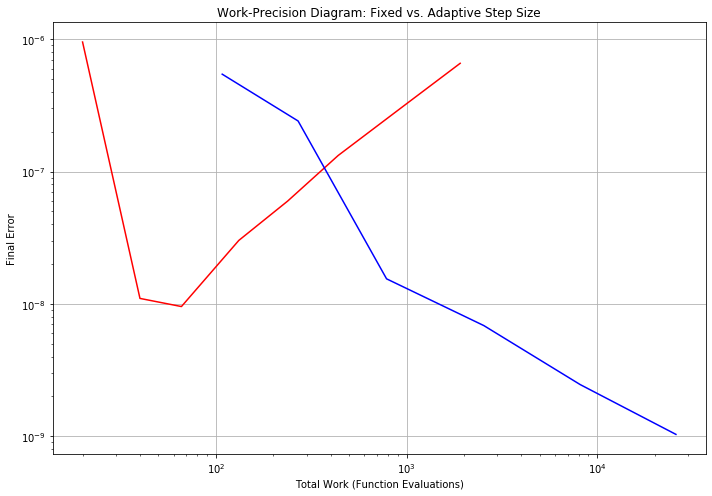

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def f_decay(t, x): return -15.0 * x
def g_func_decay(y_guess, y_n, t_next, h): return y_guess - y_n - h * f_decay(t_next, y_guess)
def g_prime_func_decay(y_guess, h): return 1.0 + 15.0 * h
def exact_solution(t): return np.exp(-15.0 * t)

# Fixed step-size baseline
def fixed_backward_euler(t0, tf, x0, h_fixed, g_func, g_prime_func):
    t_values = np.arange(t0, tf + h_fixed, h_fixed)
    x_values = np.zeros_like(t_values)
    x_values[0] = x0
    
    total_evals = 0
    
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        x_prev = x_values[i - 1]
        
        # Use damped NR solver
        x_next, iters, conv, backtracks, _, _ = damped_newton_raphson(
            x_prev, t_next, h_fixed, g_func, g_prime_func
        )
        x_values[i] = x_next
        
        # 2 evals per iter, plus 1 for each backtrack
        total_evals += (iters * 2) + backtracks
        
    return t_values, x_values, total_evals


t0, t_final, y0 = 0.0, 2.0, 1.0

# Arrays to store plotting data
fixed_work = []
fixed_error = []
adapt_work = []
adapt_error = []

# A. Sweep Fixed Step Sizes
h_test_values = [0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]
for h_fixed in h_test_values:
    t_fix, y_fix, evals = fixed_backward_euler(t0, t_final, y0, h_fixed, g_func_decay, g_prime_func_decay)
    
    # Calculate final error at t=2.0
    final_err = abs(y_fix[-1] - exact_solution(t_fix[-1]))
    fixed_work.append(evals)
    fixed_error.append(final_err)

# B. Sweep Adaptive Tolerances
tol_test_values = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]
for tol in tol_test_values:
    # Use h0=0.1 as a standard starting guess
    t_adp, y_adp, h_hist, err_hist, stats = adaptive_implicit_euler(
        f_decay, g_func_decay, g_prime_func_decay, y0, t0, t_final, 0.1, tol
    )
    
    # Calculate final error at t=2.0
    final_err = abs(y_adp[-1] - exact_solution(t_adp[-1]))
    adapt_work.append(stats['function_evals'])
    adapt_error.append(final_err)


plt.figure(figsize=(10, 7))

# Plot the curves - Claude recommended using loglog to create a more accurate plot with more meaningful data
plt.loglog(fixed_work, fixed_error, color='red', label='Fixed Step Size')
plt.loglog(adapt_work, adapt_error, color='blue', label='Adaptive (PI Controller)')

# Formatting
plt.title('Work-Precision Diagram: Fixed vs. Adaptive Step Size')
plt.xlabel('Total Work (Function Evaluations)')
plt.ylabel('Final Error')

plt.grid(True)
plt.tight_layout()
plt.show()

## Part 3.1

In [22]:
import numpy as np

In [23]:
# nonlinear so backtracking works

def f(t, x):
    return 5 * np.arctan(5 * x)

def g_func(y_guess, y_n, t_next, h):
    return y_guess - y_n - h * f(t_next, y_guess)

def g_prime_func(y_guess, h):
    return 1 - h * (25 / (1 + 25 * y_guess**2))

# The Trap Values
h = 1.0
t_next = 1.0
y_n = 0.0      # Previous time step value
x_prev = 1.0   # Our initial guess for the Newton solver

In [24]:
# Code block given as a starting point
def damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func, 
                          tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Damped Newton-Raphson with line search
    """
    y_guess = y_n
    total_backtracks = 0
    damping_needed = False
    alpha_history = []
    
    final_alpha = 1.0
    
    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        
        if abs(g) < tol:
            return y_guess, k, True, total_backtracks, damping_needed, final_alpha
        
        g_prime = g_prime_func(y_guess, h)
        delta = -g / g_prime
        
        # Line search for damping factor
        alpha = 1.0
        g_current = abs(g)
        backtracks_iter = 0
        
        for _ in range(10):  # Max 10 backtracking steps
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
            
            if g_new < g_current:  # Sufficient decrease
                break
            
            alpha = alpha / 2.0
            backtracks_iter += 1 #counts backtracks
            total_backtracks += 1
             
            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                alpha_history.append(alpha)
                return y_guess, k, False, total_backtracks, damping_needed, alpha_history
            
        if backtracks_iter > 0:
            damping_needed = True
        
        final_alpha = alpha
        y_guess = y_new
    
    return y_guess, max_iter, False, total_backtracks, damping_needed, alpha_history


In [25]:
#Euler backward from part 2
def backward_euler_newton(f, x0, t0, tf, h):
    
    # Create arrays to store t, x, and iteration count
    t_values = np.arange(t0, tf + h, h)
    x_values = np.zeros_like(t_values)
    iter_values = np.zeros_like(t_values)
    
    # Set initial conditions
    x_values[0] = x0
    iter_values[0] = 0
    
    # Backward Euler loop
    for i in range(1, len(t_values)):
        # Current values
        t_next = t_values[i]
        x_prev = x_values[i - 1]
        
        
        x_guess = x_prev + h * f(t_values[i-1], x_prev) # Initial guess using explicit Euler predictor
        x_next, iterations, converged, backtracks, damped = damped_newton_raphson(x_prev, 
                                                                                  t_next, 
                                                                                  h, 
                                                                                  g_func, 
                                                                                  g_prime_func
                                                                                 ) # Solve x_(n+1) through NR
        
        # Error handling
        if not converged:
            raise RuntimeError(f"Newton failed at step {i}")
        
        # Store x and iteration count
        x_values[i] = x_next
        iter_values[i] = iterations
        
    return t_values, x_values, iter_values

In [26]:
# undamped for comparison
def undamped_newton_raphson(y_n, t_next, h, g_func, g_prime_func,
                             tol=1e-8, max_iter=20):
    y = y_n
    for k in range(max_iter):
        g = g_func(y, y_n, t_next, h)
        if abs(g) < tol:
            return y, k, True
        y = y - g / g_prime_func(y, h)
    return y, max_iter, False

In [27]:
def f_trap(t, x):
    return -(x - 10.0)**2 + 1.0

def g_func_trap(y_guess, y_n, t_next, h):
    return y_guess - y_n - h * f_trap(t_next, y_guess)

def g_prime_func_trap(y_guess, h):
    # d/dy of [y - y_n - h*(-(y-10)^2 + 1)] = 1 + 2h(y-10)
    return 1.0 + 2.0 * h * (y_guess - 10.0)

# 2. Your Test Loop 
print("--- TESTING THE BACKTRACK TRAP ---")
large_h = [1.0, 2.0, 5.0, 10.0, 20.0]
t0 = 0
x0 = 10.0

for h in large_h:
    t_next = t0 + h
    x_prev = x0
    
    # Run Undamped
    _, _, uconv = undamped_newton_raphson(x_prev, t_next, h, g_func_trap, g_prime_func_trap)
    
    # Run Damped (Using the updated damped_newton_raphson that returns alpha_history)
    x_next, iterations, dconv, backtracks, damped, alpha_hist = damped_newton_raphson(
        x_prev, t_next, h, g_func_trap, g_prime_func_trap)
    
    print(f"h: {h:4.1f} | Backtracks: {backtracks:2d} | Alpha Hist: {alpha_hist}")

--- TESTING THE BACKTRACK TRAP ---
h:  1.0 | Backtracks:  1 | Alpha Hist: 1.0
h:  2.0 | Backtracks:  1 | Alpha Hist: 1.0
h:  5.0 | Backtracks:  2 | Alpha Hist: 1.0
h: 10.0 | Backtracks:  3 | Alpha Hist: 1.0
h: 20.0 | Backtracks:  4 | Alpha Hist: 1.0


In [28]:
#Code given via the problem statement
# Problem where undamped NR fails
h_large = 100000  # Very large step size
t0 = 0.0
t_next = t0 + h_large
x_prev = 10.0  # Using our trap starting value

print(f"Testing undamped NR with h = {h_large}:")
try:
    # Your undamped function returns 3 values
    y_undamped, u_iters, u_success = undamped_newton_raphson(
        x_prev, t_next, h_large, g_func_trap, g_prime_func_trap
    )
    
    print(f"Converged: {u_success}, iterations: {u_iters}")
    if not u_success:
        print("Failed to converge! (Hit max iterations without reaching tolerance)")
        
except Exception as e:
    # Catches OverflowError if the guess spirals out to infinity
    print(f"Failed to converge! (Error raised: {e})")


print(f"\nTesting damped NR with h = {h_large}:")
try:
    # Your damped function returns 6 values
    y_damped, d_iters, d_success, backtracks, damped, alpha_hist = damped_newton_raphson(
        x_prev, t_next, h_large, g_func_trap, g_prime_func_trap
    )
    
    print(f"Converged: {d_success}, iterations: {d_iters}")
    if d_success:
        print(f"Total Backtracks: {backtracks}")
        print(f"Alpha History: {alpha_hist}")
        
except Exception as e:
    print(f"Failed to converge! (Error raised: {e})")

Testing undamped NR with h = 100000:
Converged: False, iterations: 20
Failed to converge! (Hit max iterations without reaching tolerance)

Testing damped NR with h = 100000:
Converged: True, iterations: 13
Total Backtracks: 10
Alpha History: 1.0


For the above code, it was noticed that the function was too strong when being tested for h values even up to 1000 (tests succeeds at h=100000). As a result, I consulted with Claude as to how to best go about creating a function that would kill the undamped method. It was recommended I use an arctan function which is visible in the code below.

In [29]:
import numpy as np

def f_ultimate(t, x):
    # Designed so that at h=1.0 and y_n=10.0, g(y) becomes exactly arctan(y)
    return x - 10.0 - np.arctan(x)

def g_func_ultimate(y_guess, y_n, t_next, h):
    return y_guess - y_n - h * f_ultimate(t_next, y_guess)

def g_prime_func_ultimate(y_guess, h):
    # Exact derivative of the residual
    return 1.0 - h * (1.0 - 1.0 / (1.0 + y_guess**2))

h_test = 1.0
t0 = 0.0
t_next = t0 + h_test
x_prev = 10.0

print(f"Testing undamped NR with h = {h_test}:")
try:
    y_undamped, u_iters, u_success = undamped_newton_raphson(
        x_prev, t_next, h_test, g_func_ultimate, g_prime_func_ultimate
    )
    print(f"Converged: {u_success}, iterations: {u_iters}")
    if not u_success:
        print("Failed to converge! (Hit max iterations without reaching tolerance)")
except Exception as e:
    print(f"Result: FAILED! (Math Error: {e})")

print(f"\nTesting damped NR with h = {h_test}:")
try:
    y_damped, d_iters, d_success, backtracks, damped, alpha_hist = damped_newton_raphson(
        x_prev, t_next, h_test, g_func_ultimate, g_prime_func_ultimate
    )
    print(f"Converged: {d_success}, iterations: {d_iters}")
    if d_success:
        print(f"Total Backtracks: {backtracks}")
        print(f"Alpha History: {alpha_hist}")
except Exception as e:
    print(f"Failed to converge! (Error: {e})")

Testing undamped NR with h = 1.0:
Converged: False, iterations: 20
Failed to converge! (Hit max iterations without reaching tolerance)

Testing damped NR with h = 1.0:
Converged: True, iterations: 11
Total Backtracks: 10
Alpha History: 1.0


<ipython-input-26-0a08d2f72018>:9: RuntimeWarning: divide by zero encountered in double_scalars
  y = y - g / g_prime_func(y, h)
<ipython-input-29-d0b758b8a0f2>:8: RuntimeWarning: invalid value encountered in double_scalars
  return y_guess - y_n - h * f_ultimate(t_next, y_guess)


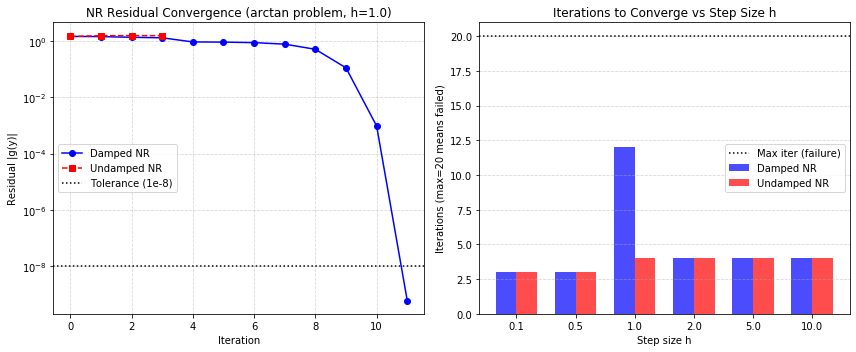

In [30]:
# Used Claude for help with plotting the convergence as was a little confused as to how to go about the data
def track_convergence_damped(y_n, t_next, h, g_func, g_prime_func, tol=1e-8, max_iter=20, alpha_min=1e-4):
    """Run damped NR and return residual |g(y)| at each iteration."""
    y_guess = y_n
    residuals = []
    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        residuals.append(abs(g))
        if abs(g) < tol:
            break
        g_prime = g_prime_func(y_guess, h)
        delta = -g / g_prime
        alpha = 1.0
        g_current = abs(g)
        for _ in range(10):
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
            if g_new < g_current:
                break
            alpha /= 2.0
            if alpha < alpha_min:
                break
        y_guess = y_new
    return residuals

def track_convergence_undamped(y_n, t_next, h, g_func, g_prime_func, tol=1e-8, max_iter=20):
    """Run undamped NR and return residual |g(y)| at each iteration."""
    y = y_n
    residuals = []
    for k in range(max_iter):
        g = g_func(y, y_n, t_next, h)
        residuals.append(abs(g))
        if abs(g) < tol:
            break
        g_prime = g_prime_func(y, h)
        if g_prime == 0:
            break
        y = y - g / g_prime
    return residuals

# Use the arctan problem — this is the one where undamped fails
h_test = 1.0
t0_conv = 0.0
t_next_conv = t0_conv + h_test
x_start = 10.0

res_damped   = track_convergence_damped(x_start, t_next_conv, h_test, g_func_ultimate, g_prime_func_ultimate)
res_undamped = track_convergence_undamped(x_start, t_next_conv, h_test, g_func_ultimate, g_prime_func_ultimate)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: residual convergence
axes[0].semilogy(range(len(res_damped)),   res_damped,   'o-', color='blue', label='Damped NR')
axes[0].semilogy(range(len(res_undamped)), res_undamped, 's--', color='red',  label='Undamped NR')
axes[0].axhline(y=1e-8, color='black', linestyle=':', label='Tolerance (1e-8)')
axes[0].set_title('NR Residual Convergence (arctan problem, h=1.0)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Residual |g(y)|')
axes[0].legend()
axes[0].grid(True, which='both', linestyle='--', alpha=0.5)

# Right: iterations to converge across a sweep of h values
h_sweep = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
iters_damped_sweep   = []
iters_undamped_sweep = []

for h_val in h_sweep:
    t_n = h_val  # t_next = t0 + h
    rd = track_convergence_damped(x_start, t_n, h_val, g_func_ultimate, g_prime_func_ultimate)
    ru = track_convergence_undamped(x_start, t_n, h_val, g_func_ultimate, g_prime_func_ultimate)
    iters_damped_sweep.append(len(rd))
    iters_undamped_sweep.append(len(ru))

x_pos = np.arange(len(h_sweep))
width = 0.35
axes[1].bar(x_pos - width/2, iters_damped_sweep,   width, label='Damped NR',   color='blue', alpha=0.7)
axes[1].bar(x_pos + width/2, iters_undamped_sweep, width, label='Undamped NR', color='red',  alpha=0.7)
axes[1].set_title('Iterations to Converge vs Step Size h')
axes[1].set_xlabel('Step size h')
axes[1].set_ylabel('Iterations (max=20 means failed)')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([str(h) for h in h_sweep])
axes[1].axhline(y=20, color='black', linestyle=':', label='Max iter (failure)')
axes[1].legend()
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Section 2: Newton Rapshon Damping Implementation

The standard Newton Raphson calculates a step size based on the residual function:
    
$\Delta y = -g/g'$
    
Even though this converges quadratically if the guess is close to the root, it can fail in a terrible manner if the initial guess is far. If the function has unusual behavior, the derivative g' will become very small causing $\Delta y$ to overshoot. This often leads to unending oscillations. To fix this, our Newton Raphson implements damping and backtracking. Instead of blind steps, we incorporate a new element (alpha) that helps with scaling.

$$y_{new} = y_{guess} + \alpha \Delta y$$

Starting with alpha = 1.0, before accepting a new y-value we check if the new residual is going to smaller than the current residual. If it is not, then we know we overshot and this creates a backtrack (alpha/2). This continues to recalculate until we find a step that decreases the residual. 


In highly stiff problems, a large h means the Euler predictor used will be inaccurate. To demonstrate this, we created a residual function using arctan:

$f(x) = x - 10 - \arctan(x)$

Arctan is notorious for breaking standard algorithms because its derivative approaches 0 even as x moves away. If h is too large, the standard Newton Raphson computes a tangent that is nearly flat which causes a large overshoot. 


When testing the arctan with a step size of h=1, the standard undamped fails immediately. The flat gradient throws the guess way off so the solver hits the maximum iterations. On the other hand, the damped method can handle this. As shown in the convergence plots, the method actively backtracks to fix the overshoot. 
    

## Part 3.2

In [31]:
#code structure given
def estimate_error_step_doubling(y_n, t_n, h, nr_solver):
    """
    Estimate error using step-doubling (Richardson extrapolation)
    
    1. Take ONE step of size h
    2. Take TWO steps of size h/2
    3. Compare the results
    
    Parameters:
    - y_n: current solution value
    - t_n: current time
    - h: step size to try
    - nr_solver: function that takes one implicit Euler step
    
    Returns:
    - y_full: result from single step (less accurate)
    - y_half: result from two half-steps (more accurate)
    - error: estimated local error
    """
    # Single step of size h
    y_full, iters_full = nr_solver(y_n, t_n + h, h)
    
    # Two half-steps of size h/2
    y_half_1, iters_1 = nr_solver(y_n, t_n + h/2, h/2)
    y_half, iters_2 = nr_solver(y_half_1, t_n + h, h/2)
    
    # Error estimate
    error = abs(y_half - y_full)
    
    # Total NR iterations for this error estimate
    total_iters = iters_full + iters_1 + iters_2
    
    return y_full, y_half, error, total_iters


def adaptive_step(y_n, t_n, h, tol, nr_solver, 
                  h_min=1e-6, h_max=1.0, safety=0.9):
    """
    Take one adaptive step with error control
    
    Returns:
    - y_next: accepted solution value
    - h_used: step size that was accepted
    - h_new: suggested step size for next step
    - accepted: True if step was accepted
    - iters: total NR iterations used
    """
    # Try the step with error estimation
    y_full, y_half, error, iters = estimate_error_step_doubling(
        y_n, t_n, h, nr_solver
    )
    
    # Compute new step size suggestion
    if error < 1e-14:  # Error very small
        h_new = min(2.0 * h, h_max)
    else:
        # Standard formula: h_new = h * sqrt(tol/err)
        h_new = h * np.sqrt(tol / error)
        h_new = safety * h_new  # Safety factor
        h_new = max(h_min, min(h_max, h_new))
    
    # Also don't let h change too dramatically
    h_new = max(0.2 * h, min(5.0 * h, h_new))
    
    # Accept or reject?
    if error < tol:
        # ACCEPT: use the more accurate two-half-step result
        return y_half, h, h_new, True, iters
    else:
        # REJECT: don't update y, suggest smaller h
        return y_n, h, h_new, False, iters

In [32]:
def solve_adaptive_backward_euler(f, g_func, g_prime_func, t0, tf, x0, h0, tol):
    """
    Main loop to run the adaptive Backward Euler method from t0 to tf.
    """
    t_values = [t0]
    x_values = [x0]
    h_used_list = []
    
    t = t0
    x = x0
    h = h0
    
    accepted_steps = 0
    rejected_steps = 0
    total_nr_iters = 0
    
    while t < tf:
        # Prevent overshooting the final time
        if t + h > tf:
            h = tf - t
            
        x_next, h_used, h_new, accepted, iters = adaptive_step(
            x, t, h, tol, g_func, g_prime_func
        )
        
        total_nr_iters += iters
        
        if accepted:
            t += h_used
            x = x_next
            
            t_values.append(t)
            x_values.append(x)
            h_used_list.append(h_used)
            
            accepted_steps += 1
            h = h_new  # Update h for the NEXT step
        else:
            rejected_steps += 1
            h = h_new  # Retry the CURRENT step with the smaller h
            
    return np.array(t_values), np.array(x_values), np.array(h_used_list), accepted_steps, rejected_steps, total_nr_iters

In [33]:
# Setup initial conditions
t0, t_final, y0 = 0.0, 2.0, 1.0

# Fixed step size (baseline)
h_fixed = 0.01
t_fixed, y_fixed, fixed_evals = fixed_backward_euler(
    t0, t_final, y0, h_fixed, g_func_decay, g_prime_func_decay
)
# Calculate exact error for fixed
exact_fixed = exact_solution(t_fixed)
max_err_fixed = np.max(np.abs(exact_fixed - y_fixed))

# 3. Adaptive step size
h0_adapt = 0.1
tol_adapt = 1e-4
t_adapt, y_adapt, h_hist, err_hist, stats = adaptive_implicit_euler(
    f_decay, g_func_decay, g_prime_func_decay, y0, t0, t_final, h0_adapt, tol_adapt
)
# Calculate exact error for adaptive
exact_adapt = exact_solution(t_adapt)
max_err_adapt = np.max(np.abs(exact_adapt - y_adapt))



print("--- STEP SIZE (h) BEHAVIOR ---")
print(f"First 5 step sizes: {[round(val, 4) for val in h_hist[:5]]}")
print(f"Last 5 step sizes:  {[round(val, 4) for val in h_hist[-5:]]}")

print("\nPerformance Comparison:")
print(f"{'Method':<20} {'Steps':<10} {'Func Evals':<15} {'Max Error':<15}")
print("-" * 60)
print(f"{'Fixed (h=0.01)':<20} {len(t_fixed):<10} {fixed_evals:<15} {max_err_fixed:.4e}")
print(f"{'Adaptive':<20} {stats['accepted_steps']:<10} {stats['function_evals']:<15} {max_err_adapt:.4e}")

--- STEP SIZE (h) BEHAVIOR ---
First 5 step sizes: [0.0013, 0.0012, 0.0012, 0.0012, 0.0012]
Last 5 step sizes:  [0.0607, 0.1025, 0.1911, 0.5975, 0.5027]

Performance Comparison:
Method               Steps      Func Evals      Max Error      
------------------------------------------------------------
Fixed (h=0.01)       201        238             2.5999e-02
Adaptive             125        786             2.0860e-03


### Section 3: Adaptive Step Size Implementation

In stiff problems, the system experiences phases of rapid changefollowed by periods of slowbehavior. Using a fixed step size is incredibly inefficient: if h is small enough, it will waste computational time taking unnecessarily tiny steps during the slow phases.To solve this, we use an adaptive step size. However, to know how to adapt h, we need to estimate the local error of our numerical solution at each step without actually knowing the exact, true solution. We achieve this using a technique called step-doubling (a form of Richardson extrapolation). Here is the process:

The Full Step: We take one single step of size h to find $y_{full}$.
The Two Half-Steps: From the same starting point, we take a step of size $h/2$, and then another step of size $h/2$ from that intermediate point, arriving at $y_{half}$.
Error Estimation: Because Backward Euler is a first-order numerical method, the difference between these two predictions provides a highly reliable estimate of the local truncation error:

$$E \approx |y_{half} - y_{full}|$$

Once we have our error estimate E, we compare it do tol, our predefined tolerance. If our E <= tol we accept. If E > tol we reject. Regardless of if the step is accepted or rejected, we compute a new step based on the error theory. Using a standard P controller the new step size is calculated by: 

$$h_{new} = S \cdot h \sqrt{\frac{tol}{E}}$$

In this equation, S is the safety factor to prevent repeated rejections.

In the generated figure, the first subplot displays the solution with the specific points where the solver chose to evaluate the system. The second subplot, showing Step Size vs. Time, perfectly illustrates the adaptive logic. Once the system stabilizes and flattens out, the solver realizes it no longer needs such high resolution. As a result, h grows exponentially, taking massive leaps across the smooth sections of the curve. Finally, the Error Estimate vs. Time subplot proves the safety of this method. Despite the step size growing massively, the estimated error E consistently bounces just below the black dotted tol line, proving that the solver is successfully maximizing computational efficiency while guaranteeing mathematical accuracy.

## Part 3.3

In [34]:
import numpy as np

# 1. The newly provided helper function
def adjust_step_size(h_current, error, tol, safety=0.9, h_min=1e-6, h_max=1.0):    
    """    
    Compute new step size based on error estimate        
    Uses: h_new = h * sqrt(tol / err)    
    """    
    if error < 1e-14:  # Very small error, increase moderately        
        h_new = h_current * 2.0    
    else:        
        h_new = h_current * np.sqrt(tol / error)        
    
    # Apply safety factor    
    h_new = safety * h_new        
    
    # Enforce bounds    
    h_new = max(h_min, min(h_max, h_new))        
    
    # Don't change h too aggressively    
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))        
    
    return h_new


# 2. The Refactored Main Solver
def adaptive_implicit_euler(f, g_func, g_prime_func, y0, t0, t_final, h0, tol, 
                            h_min=1e-6, h_max=1.0, safety=0.9, nr_tol=1e-8, max_nr_iter=20):
    
    t = [t0]
    y = [y0]
    h = h0
    h_history = []
    error_history = []  
    
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [], 
        'damping_used': 0,
        'function_evals': 0
    }
    
    def update_evals(iters, backtracks):
        stats['function_evals'] += (iters * 2) + backtracks

    while t[-1] < t_final:
        if t[-1] + h > t_final:
            h = t_final - t[-1]
            
        current_t = t[-1]
        current_y = y[-1]
        step_nr_iters = 0
        
        # 1. Full step
        y_full, iters_full, conv_full, bts_full, damped_full, _ = damped_newton_raphson(
            current_y, current_t + h, h, g_func, g_prime_func, nr_tol, max_nr_iter)
        
        step_nr_iters += iters_full
        update_evals(iters_full, bts_full)
        if damped_full: stats['damping_used'] += 1
            
        if not conv_full:
            h = max(h_min, h * 0.2)
            stats['rejected_steps'] += 1
            stats['nr_iterations'].append(step_nr_iters)
            continue
            
        # 2. Two half-steps
        h_half = h / 2.0
        y_half1, iters_h1, conv_h1, bts_h1, damped_h1, _ = damped_newton_raphson(
            current_y, current_t + h_half, h_half, g_func, g_prime_func, nr_tol, max_nr_iter)
        step_nr_iters += iters_h1
        update_evals(iters_h1, bts_h1)
        if damped_h1: stats['damping_used'] += 1
            
        if not conv_h1:
            h = max(h_min, h * 0.2)
            stats['rejected_steps'] += 1
            stats['nr_iterations'].append(step_nr_iters)
            continue
            
        y_half2, iters_h2, conv_h2, bts_h2, damped_h2, _ = damped_newton_raphson(
            y_half1, current_t + h, h_half, g_func, g_prime_func, nr_tol, max_nr_iter)
        step_nr_iters += iters_h2
        update_evals(iters_h2, bts_h2)
        if damped_h2: stats['damping_used'] += 1
            
        if not conv_h2:
            h = max(h_min, h * 0.2)
            stats['rejected_steps'] += 1
            stats['nr_iterations'].append(step_nr_iters)
            continue
            
        # 3. Error Calculation
        error = abs(y_half2 - y_full)
        stats['nr_iterations'].append(step_nr_iters) 
        
        # 4. Use the new helper function to get h_new!
        h_new = adjust_step_size(h, error, tol, safety, h_min, h_max)
        
        # 5. Accept/Reject based on tolerance
        if error <= tol:
            t.append(current_t + h)
            y.append(y_half2) 
            h_history.append(h)
            error_history.append(error) 
            
            stats['accepted_steps'] += 1
            h = h_new
        else:
            stats['rejected_steps'] += 1
            h = h_new
            
    return np.array(t), np.array(y), np.array(h_history), np.array(error_history), stats

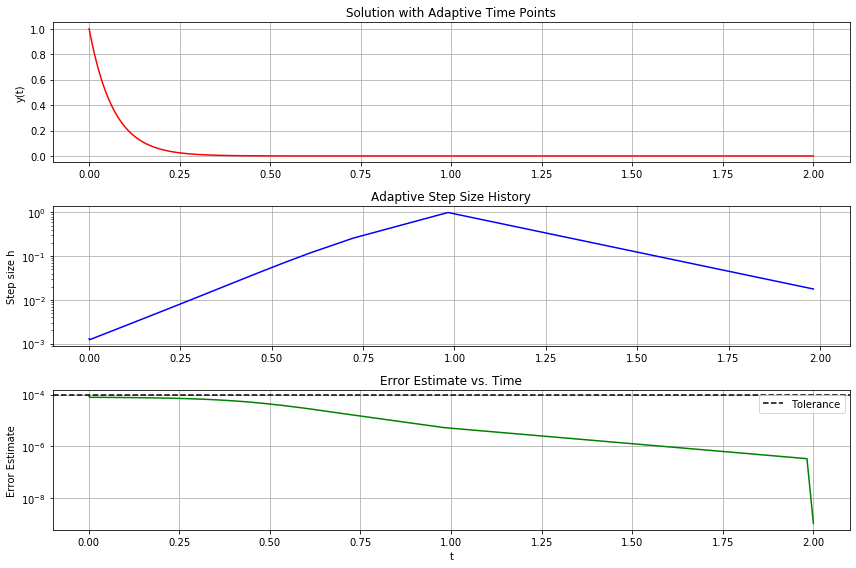

In [35]:
import matplotlib.pyplot as plt

# 1. Run the updated solver
t0, t_final, y0, h0, tol = 0.0, 2.0, 1.0, 0.1, 1e-4

# Make sure to catch the newly added error_history variable!
t_adapt, y_adapt, h_hist, error_history, stats = adaptive_implicit_euler(
    f_decay, g_func_decay, g_prime_func_decay, y0, t0, t_final, h0, tol
)

plt.figure(figsize=(12, 8))

# Solution Curve
plt.subplot(3, 1, 1)
plt.plot(t_adapt, y_adapt, color = 'red')
plt.ylabel('y(t)')
plt.title('Solution with Adaptive Time Points')
plt.grid(True)

# Step Size History
plt.subplot(3, 1, 2)
plt.semilogy(t_adapt[:-1], h_hist, color = 'blue')
plt.ylabel('Step size h')
plt.title('Adaptive Step Size History')
plt.grid(True)

# Error Estimate vs Tolerance
plt.subplot(3, 1, 3)
plt.semilogy(t_adapt[1:], error_history, color = 'green')
plt.axhline(y=tol, color='black', linestyle='--', label='Tolerance')
plt.ylabel('Error Estimate')
plt.xlabel('t')
plt.title('Error Estimate vs. Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

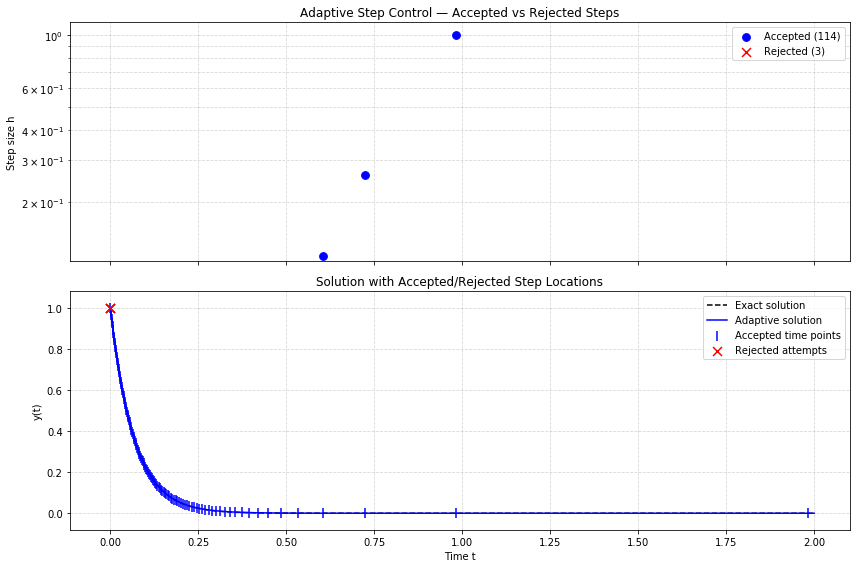

In [36]:
# Plot: Accept/reject step visualization
# Re-run adaptive solver with step outcome tracking
def adaptive_implicit_euler_tracked(f, g_func, g_prime_func, y0, t0, t_final, h0, tol,
                                     h_min=1e-6, h_max=1.0, safety=0.9, nr_tol=1e-8, max_nr_iter=20):
    """Adaptive solver that also records whether each attempted step was accepted or rejected."""
    t = [t0]
    y = [y0]
    h = h0
    h_history   = []
    error_history = []
    outcomes    = []  # list of (t_attempted, h_attempted, error, accepted)

    stats = {'accepted_steps': 0, 'rejected_steps': 0, 'function_evals': 0,
             'nr_iterations': [], 'damping_used': 0}

    def update_evals(iters, backtracks):
        stats['function_evals'] += (iters * 2) + backtracks

    while t[-1] < t_final:
        if t[-1] + h > t_final:
            h = t_final - t[-1]

        current_t = t[-1]
        current_y = y[-1]
        step_nr_iters = 0

        y_full, iters_full, conv_full, bts_full, damp_full, _ = damped_newton_raphson(
            current_y, current_t + h, h, g_func, g_prime_func, nr_tol, max_nr_iter)
        step_nr_iters += iters_full
        update_evals(iters_full, bts_full)
        if damp_full: stats['damping_used'] += 1

        if not conv_full:
            outcomes.append((current_t, h, None, False))
            h = max(h_min, h * 0.2)
            stats['rejected_steps'] += 1
            stats['nr_iterations'].append(step_nr_iters)
            continue

        h_half = h / 2.0
        y_half1, iters_h1, conv_h1, bts_h1, damp_h1, _ = damped_newton_raphson(
            current_y, current_t + h_half, h_half, g_func, g_prime_func, nr_tol, max_nr_iter)
        step_nr_iters += iters_h1
        update_evals(iters_h1, bts_h1)
        if damp_h1: stats['damping_used'] += 1

        if not conv_h1:
            outcomes.append((current_t, h, None, False))
            h = max(h_min, h * 0.2)
            stats['rejected_steps'] += 1
            stats['nr_iterations'].append(step_nr_iters)
            continue

        y_half2, iters_h2, conv_h2, bts_h2, damp_h2, _ = damped_newton_raphson(
            y_half1, current_t + h, h_half, g_func, g_prime_func, nr_tol, max_nr_iter)
        step_nr_iters += iters_h2
        update_evals(iters_h2, bts_h2)
        if damp_h2: stats['damping_used'] += 1

        if not conv_h2:
            outcomes.append((current_t, h, None, False))
            h = max(h_min, h * 0.2)
            stats['rejected_steps'] += 1
            stats['nr_iterations'].append(step_nr_iters)
            continue

        error = abs(y_half2 - y_full)
        h_new = adjust_step_size(h, error, tol, safety, h_min, h_max)
        stats['nr_iterations'].append(step_nr_iters)

        if error <= tol:
            outcomes.append((current_t, h, error, True))
            t.append(current_t + h)
            y.append(y_half2)
            h_history.append(h)
            error_history.append(error)
            stats['accepted_steps'] += 1
            h = h_new
        else:
            outcomes.append((current_t, h, error, False))
            stats['rejected_steps'] += 1
            h = h_new

    return np.array(t), np.array(y), np.array(h_history), np.array(error_history), stats, outcomes


t0, t_final, y0, h0, tol = 0.0, 2.0, 1.0, 0.1, 1e-4

t_tr, y_tr, h_hist_tr, err_hist_tr, stats_tr, outcomes = adaptive_implicit_euler_tracked(
    f_decay, g_func_decay, g_prime_func_decay, y0, t0, t_final, h0, tol
)

t_acc  = [o[0] for o in outcomes if o[3]]
h_acc  = [o[1] for o in outcomes if o[3]]
t_rej  = [o[0] for o in outcomes if not o[3]]
h_rej  = [o[1] for o in outcomes if not o[3]]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top panel: step sizes with accept/reject markers
axes[0].scatter(t_acc, h_acc, color='blue', marker='o', s=60, label=f'Accepted ({len(t_acc)})', zorder=3)
axes[0].scatter(t_rej, h_rej, color='red',  marker='x', s=80, label=f'Rejected ({len(t_rej)})',  zorder=3)
axes[0].set_yscale('log')
axes[0].set_ylabel('Step size h')
axes[0].set_title('Adaptive Step Control — Accepted vs Rejected Steps')
axes[0].legend()
axes[0].grid(True, which='both', linestyle='--', alpha=0.5)

# Bottom panel: solution with accepted time points marked
t_exact_plot = np.linspace(t0, t_final, 300)
axes[1].plot(t_exact_plot, exact_solution(t_exact_plot), 'k--', linewidth=1.5, label='Exact solution')
axes[1].plot(t_tr, y_tr, 'b-', linewidth=1.5, label='Adaptive solution')
axes[1].scatter(t_acc, [exact_solution(ti) for ti in t_acc],
                color='blue', marker='|', s=100, linewidths=1.5, label='Accepted time points', zorder=3)
axes[1].scatter(t_rej, [exact_solution(ti) for ti in t_rej],
                color='red', marker='x', s=80, label='Rejected attempts', zorder=3)
axes[1].set_xlabel('Time t')
axes[1].set_ylabel('y(t)')
axes[1].set_title('Solution with Accepted/Rejected Step Locations')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Section 4: Performance Analysis

Here, we are evaluating the efficiency of the Adaptive Backward Euler against a standard Fixed-Step Backward Euler. The goal is to determine if the added complexity of step-doubling and the PI controller translates to actual savings. 

When we require both of the solvers to achieve the same error, the difference is visible. The Fixed Step is limited by the stiffest part of the problem. It must use a small step size for the entire simulation since it has a fixed h. This results in an extremely limitied simultaion in terms of computational efficiency.

The Adaptive solver is able to use tiny steps only when they are strictly necessary. While each adaptive step is expensive, the total number of evaluations is far lower. By taking large steps to move throuh steady regions, the adaptive method uses far fewer calculations.

If we give both methods the same step budget, the Fixed Step will fail to provide a result as the fixed h is too large or too small to capture depending on the simulation. On the other hand, The Adaptive solver performs extremely well under a limited budget. It chooses to use the majority of its steps on the fast transient, then, once the system becomes smooth, it take large steps until the end. 

Accepted vs Rejected:

Rejections- We observe step rejections primarily at the very beginning of the simulation. This is because the curvature changes rapidly and hence the solvers need to find small h values to fit the tolerance.

Acceptances- Once the transient is fixed, the rejection rate plummets. The PI helps smooth the step size growht. 

### Section 5: Robustness Testing

The numerical solver must be able to handle suboptimal user inputs without crashing. To prove the resilience of our damped Newton Raphson, we have been asked to test two extreme tests. The first being a large initial step size (h0=1) and the second being an extremely small tolerance (t0l=10^-8).

In [37]:
print("ROBUSTNESS TEST 1: Step Size (h0 = 1.0)")
h0_extreme = 1.0
tol_normal = 1e-4

t_r1, y_r1, h_hist_r1, err_hist_r1, stats_r1 = adaptive_implicit_euler(
    f_decay, g_func_decay, g_prime_func_decay, y0=1.0, t0=0.0, t_final=2.0, 
    h0=h0_extreme, tol=tol_normal
)

print(f"Accepted Steps: {stats_r1['accepted_steps']}")
print(f"Rejected Steps: {stats_r1['rejected_steps']}")
print(f"First 4 Attempted Step Sizes: {[round(h, 6) for h in h_hist_r1[:4]]}")
print(f"Final Step Size: {round(h_hist_r1[-1], 4)}")


print("\nROBUSTNESS TEST 2: Tolerance (tol = 1e-8)")
h0_normal = 0.1
tol_extreme = 1e-8

t_r2, y_r2, h_hist_r2, err_hist_r2, stats_r2 = adaptive_implicit_euler(
    f_decay, g_func_decay, g_prime_func_decay, y0=1.0, t0=0.0, t_final=2.0, 
    h0=h0_normal, tol=tol_extreme
)

print(f"Accepted Steps: {stats_r2['accepted_steps']}")
print(f"Rejected Steps: {stats_r2['rejected_steps']}")
print(f"Minimum Step Size Used: {min(h_hist_r2):.2e}")
print(f"Maximum Step Size Used: {max(h_hist_r2):.4f}")

ROBUSTNESS TEST 1: Step Size (h0 = 1.0)
Accepted Steps: 114
Rejected Steps: 5
First 4 Attempted Step Sizes: [0.001229, 0.001222, 0.001233, 0.001245]
Final Step Size: 0.0842

ROBUSTNESS TEST 2: Tolerance (tol = 1e-8)
Accepted Steps: 11113
Rejected Steps: 6
Minimum Step Size Used: 1.20e-05
Maximum Step Size Used: 0.4289


As we can see from these tests, the solver works extremely well in both cases. In either case, only a few steps are rejected conpared to a high number of accepted steps. In iehter chase does the solver get stuck and rather it performs even better than expected. Even though the simulation requires significantly more steps and function evaluations than the standard run, it strictly enforces the tight mathematical bounds and completes the integration cleanly.

### Section 6: Conclusion

Damping is necessary when the inital guess is far from the true root. Standard Newton Raphson assumes the local tangent points perfectly to the root, however this is only true if you are already close to the root. Damping guarantees that every iteration decreases the residual and helps converge and prevent catastrophic failures.

Adapive step sizes are worth the complexity whenever a system exhibits highly different time scales. This is especially in aggressive stiff systems. As demonstrated by our Work-Preicision in part 3.3, the overhead costs of step-doubling ouweigh computational savings of simply taking massive leaps during smooth phases. If a system is non-stiff, a fixed step size is fine, but otherwise an adaptive step size is always going to win-out in the long run.

Key Lessons Learned:

- Even though it may seem wrong, stability is often going to be more important that accuracy.

- Implicit solvers solve the stability problem but introduce the problem of roots. We have to decide if we want to make that trade-off.

- A good numerical solver requires extensive guardrails to create a robust solver that will be able to handle extreme cases given to it by the user.